In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)

print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv'
)

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
print('=== Dataset Info ===')
print(df.info())
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Descriptive Statistics ===')
df.describe().T

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

=== Missing Values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [6]:
df.columns = [c.strip().lower() for c in df.columns]
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)}')
numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f'Remaining NaN values: {df[numeric_cols].isnull().sum().sum()}')
print(f'Final shape: {df.shape}')
df.head()

Duplicates removed: 0
Remaining NaN values: 0
Final shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


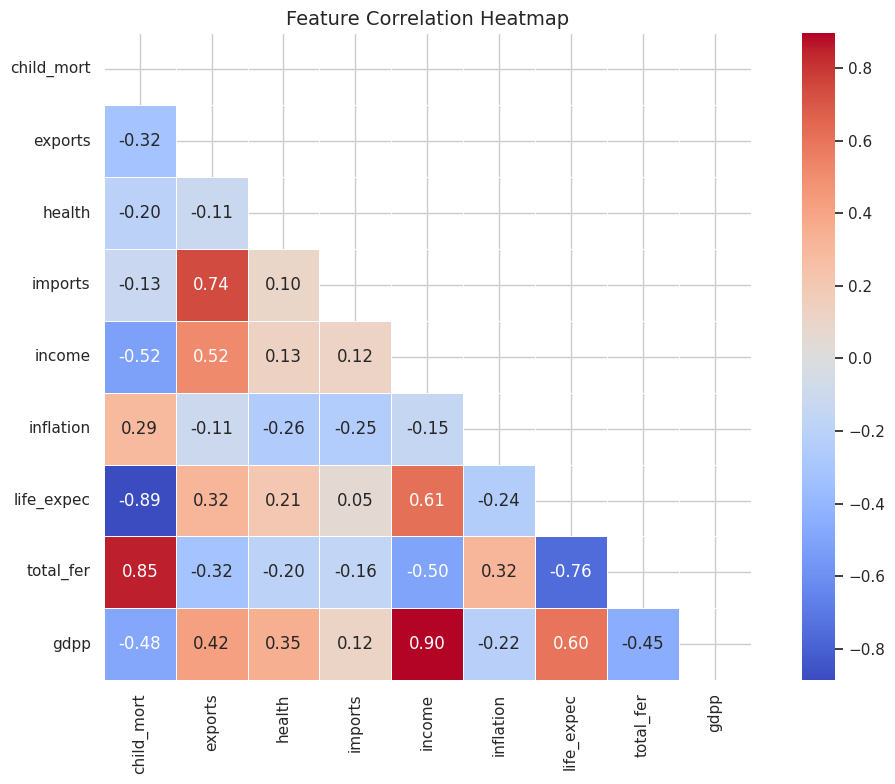

In [8]:
# ── 5a. Correlation Heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

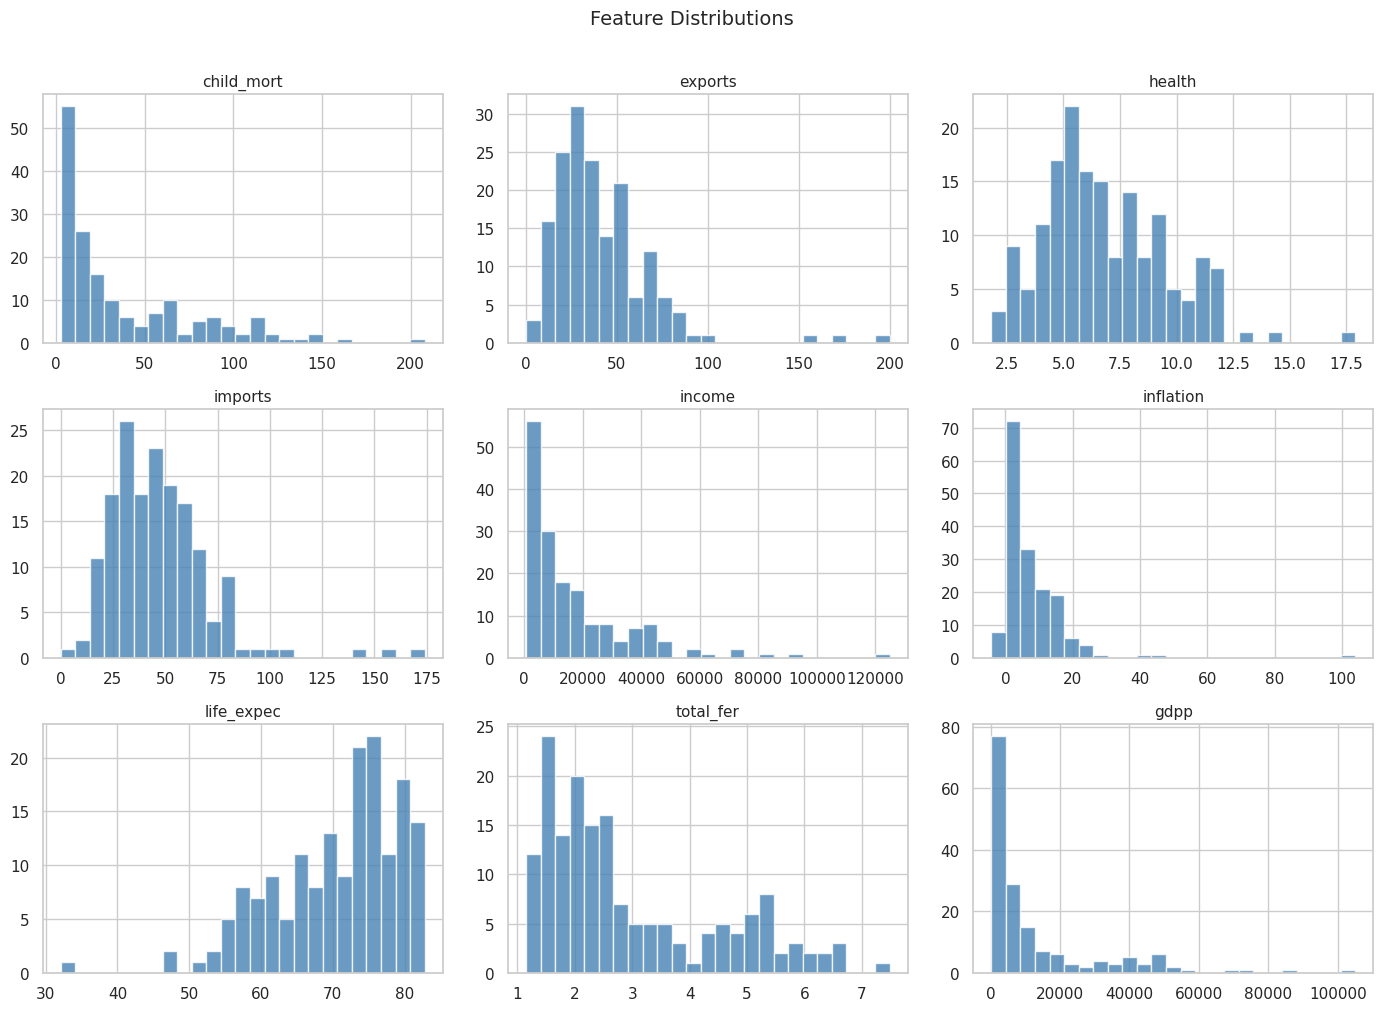

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

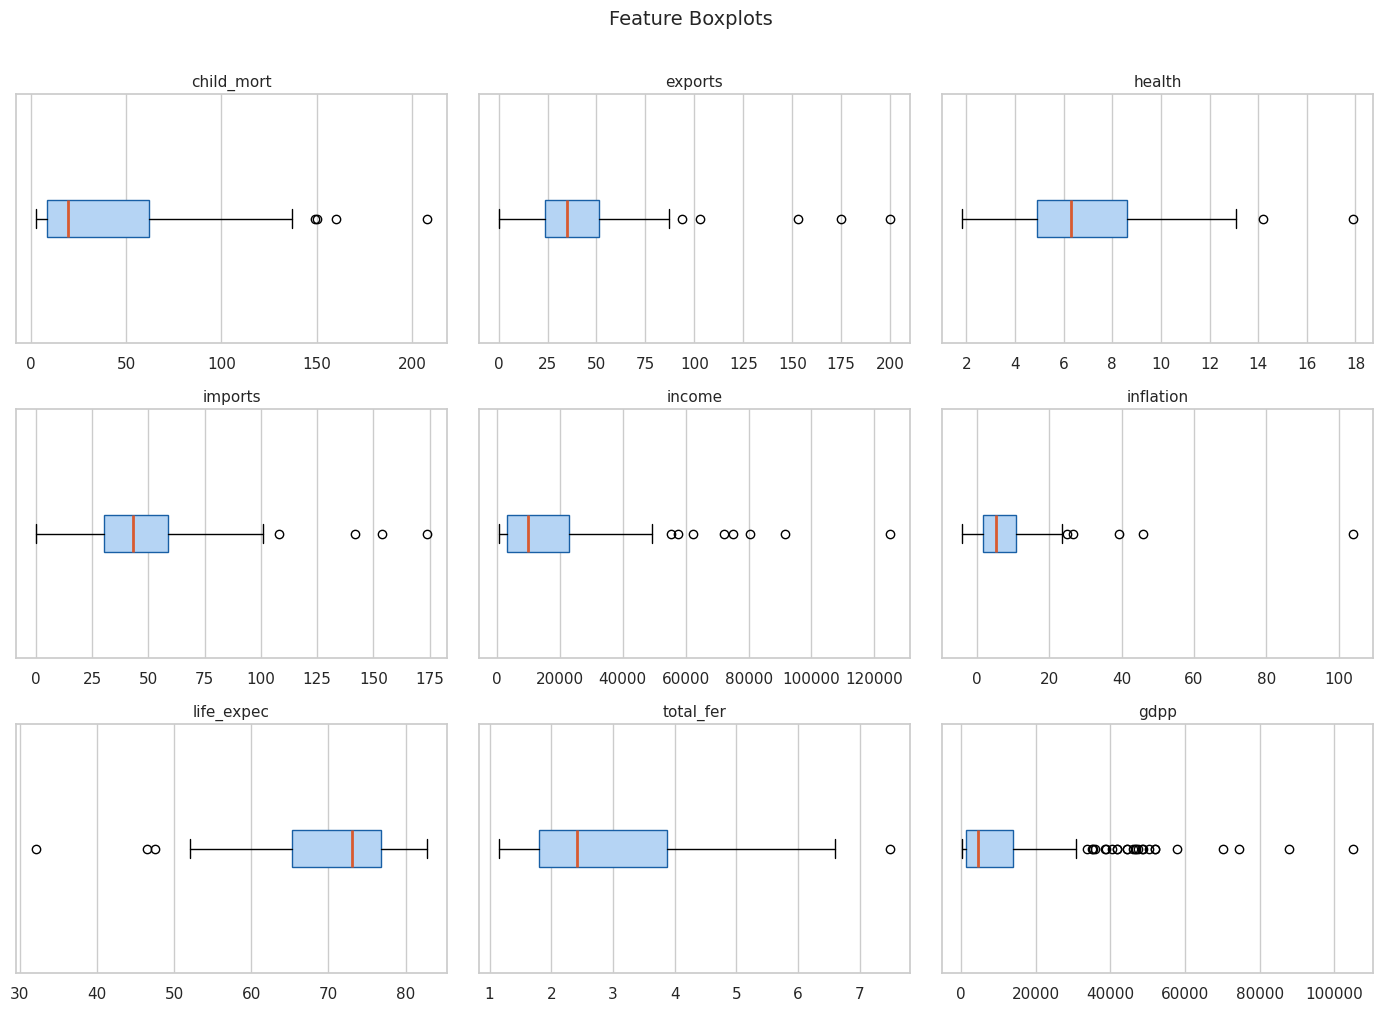

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                    medianprops=dict(color='#D85A30', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_yticks([])
plt.suptitle('Feature Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

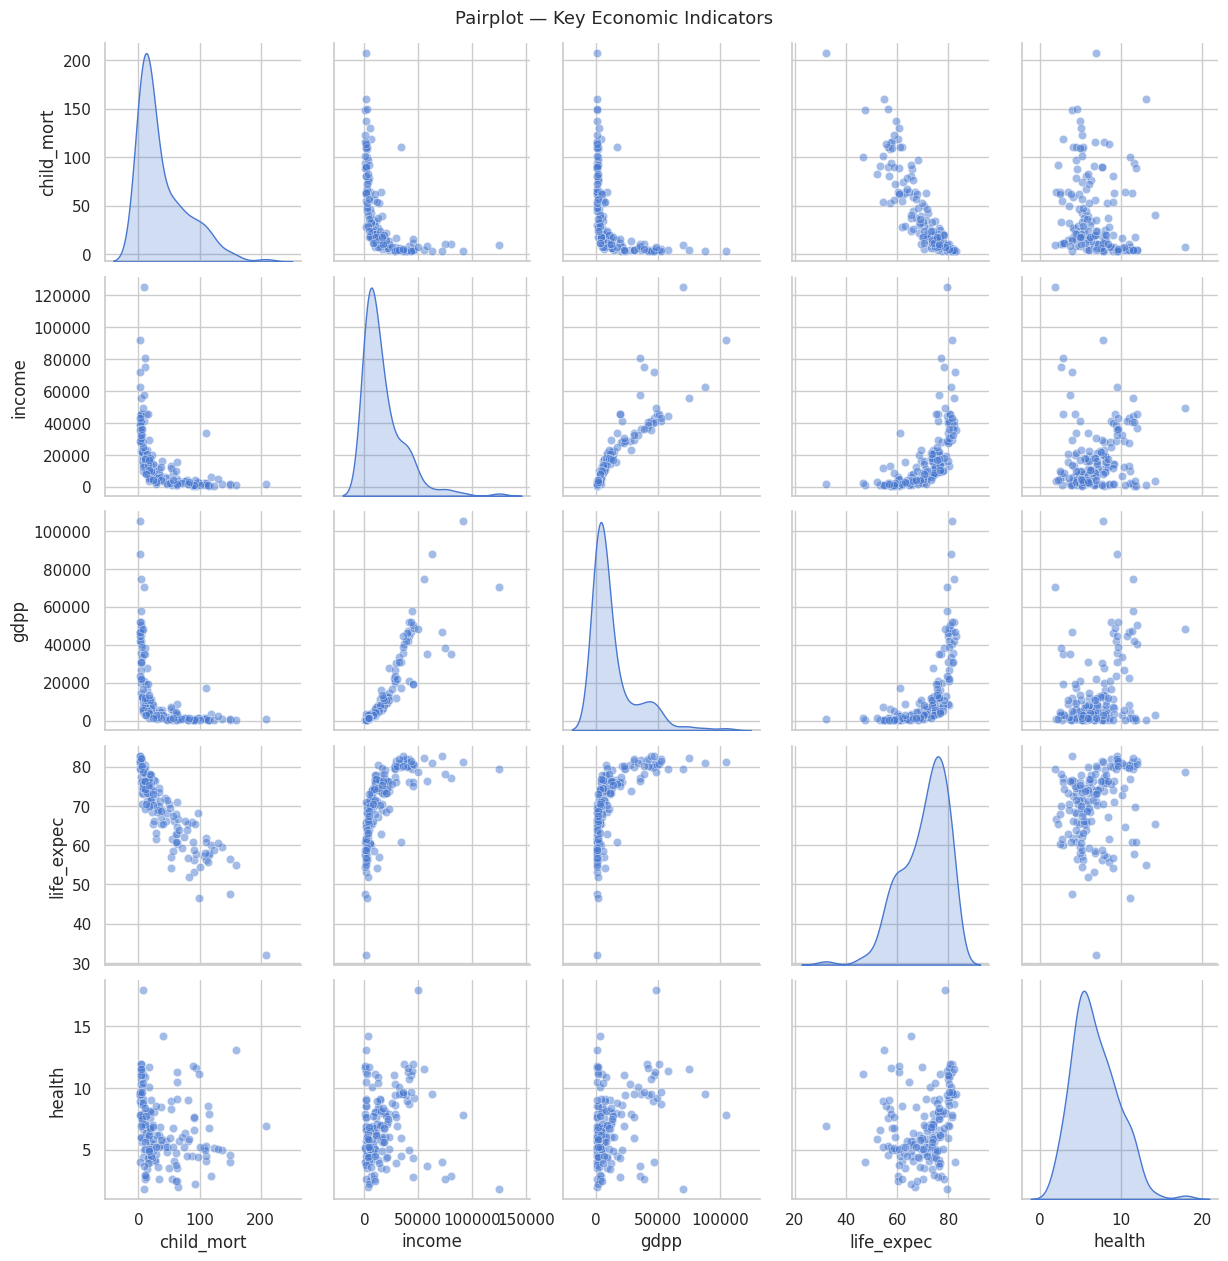

In [9]:
key_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'health']
sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — Key Economic Indicators', y=1.01, fontsize=13)
plt.show()

In [10]:
features = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(4)}')

Scaled feature matrix shape: (167, 9)
Mean (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


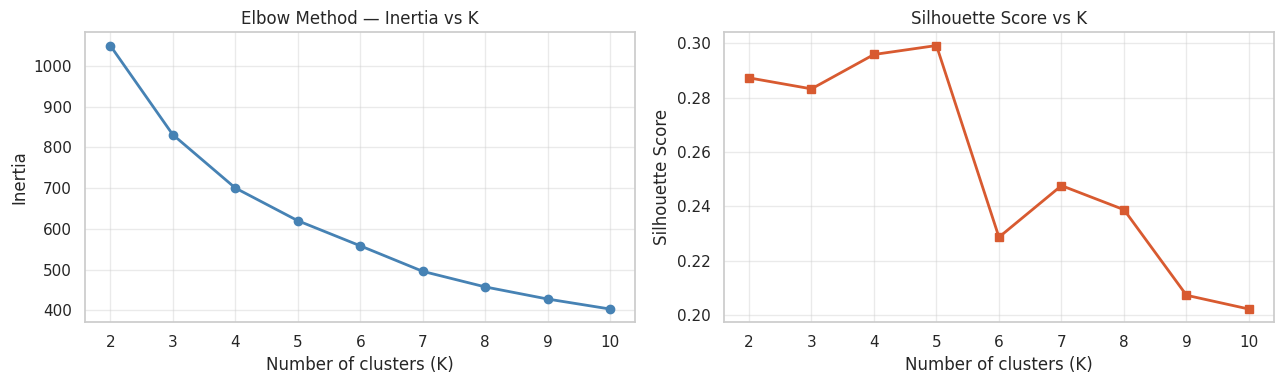

Best K by silhouette score: 5  (score = 0.2993)


In [11]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=12)
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.4)
axes[1].plot(list(k_values), sil_scores, marker='s', color='#D85A30', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=12)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
best_k_sil = k_values[sil_scores.index(max(sil_scores))]
print(f'Best K by silhouette score: {best_k_sil}  (score = {max(sil_scores):.4f})')

In [13]:
BEST_K = 3   
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f'K-Means with K={BEST_K}')
print(f'Silhouette Score : {sil:.4f}')
print(f'Inertia          : {kmeans.inertia_:.2f}')
print()
print('Cluster size distribution:')
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means with K=3
Silhouette Score : 0.2833
Inertia          : 831.42

Cluster size distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


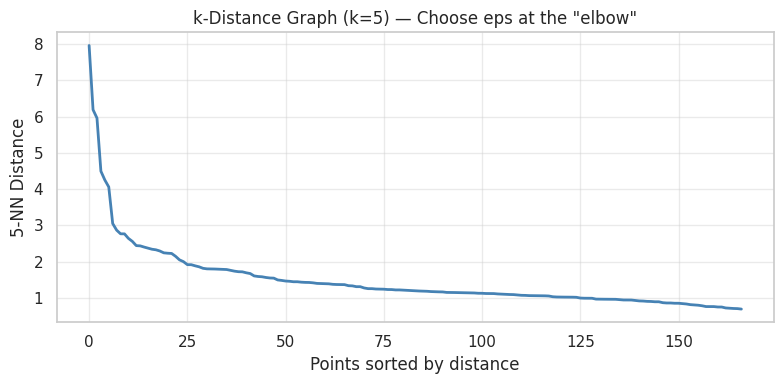

In [14]:
from sklearn.neighbors import NearestNeighbors
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
dist_sorted = np.sort(distances[:, k-1])[::-1]
plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='steelblue', linewidth=2)
plt.title(f'k-Distance Graph (k={k}) — Choose eps at the "elbow"', fontsize=12)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-NN Distance')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
EPS = 1.5
MIN_SAMPLES = 5
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise    = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN Results  (eps={EPS}, min_samples={MIN_SAMPLES})')
print(f'Clusters found  : {n_clusters}')
print(f'Noise points    : {n_noise}  (label = -1)')
print()
print('Cluster value counts:')
print(df['dbscan_cluster'].value_counts().sort_index())

DBSCAN Results  (eps=1.5, min_samples=5)
Clusters found  : 1
Noise points    : 30  (label = -1)

Cluster value counts:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


PCA explained variance  PC1=46.0%  PC2=17.2%  Total=63.1%


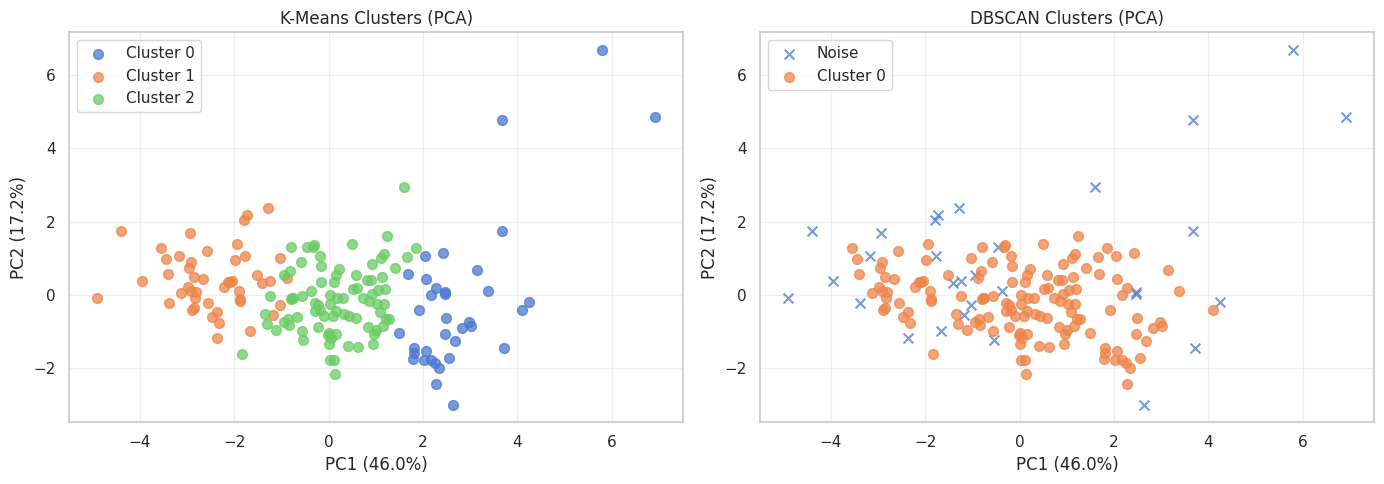

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PCA explained variance  PC1={explained[0]*100:.1f}%  PC2={explained[1]*100:.1f}%  Total={sum(explained)*100:.1f}%')

viz = pd.DataFrame({
    'PC1'    : X_pca[:, 0],
    'PC2'    : X_pca[:, 1],
    'kmeans' : df['kmeans_cluster'],
    'dbscan' : df['dbscan_cluster'],
    'country': df['country']
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in sorted(viz['kmeans'].unique()):
    sub = viz[viz['kmeans'] == c]
    axes[0].scatter(sub['PC1'], sub['PC2'], label=f'Cluster {c}', alpha=0.75, s=50)
axes[0].set_title('K-Means Clusters (PCA)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for c in sorted(viz['dbscan'].unique()):
    sub = viz[viz['dbscan'] == c]
    label = 'Noise' if c == -1 else f'Cluster {c}'
    marker = 'x' if c == -1 else 'o'
    axes[1].scatter(sub['PC1'], sub['PC2'], label=label, alpha=0.75, s=50, marker=marker)
axes[1].set_title('DBSCAN Clusters (PCA)', fontsize=12)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

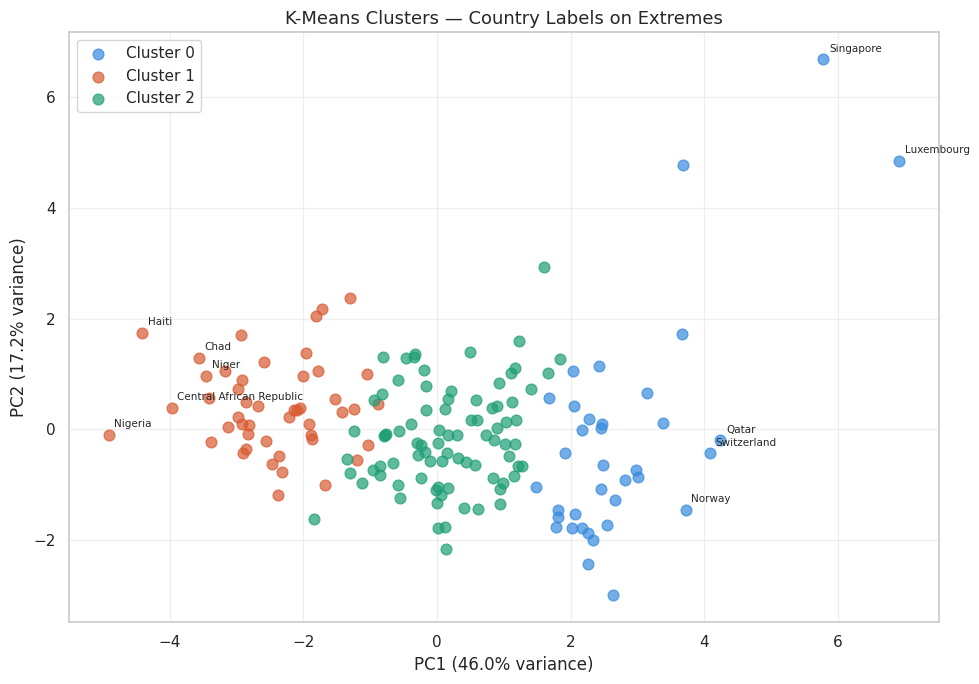

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = {0: '#378ADD', 1: '#D85A30', 2: '#1D9E75'}

for c in sorted(viz['kmeans'].unique()):
    sub = viz[viz['kmeans'] == c]
    ax.scatter(sub['PC1'], sub['PC2'],
               color=palette.get(c, 'gray'),
               label=f'Cluster {c}', alpha=0.7, s=60)
notable = viz.nlargest(5, 'PC1').index.tolist() + viz.nsmallest(5, 'PC1').index.tolist()
for idx in notable:
    row = viz.loc[idx]
    ax.annotate(row['country'], (row['PC1'], row['PC2']),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_title('K-Means Clusters — Country Labels on Extremes', fontsize=13)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
print('=== Mean Feature Values per Cluster ===')
display(profile)

=== Mean Feature Values per Cluster ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


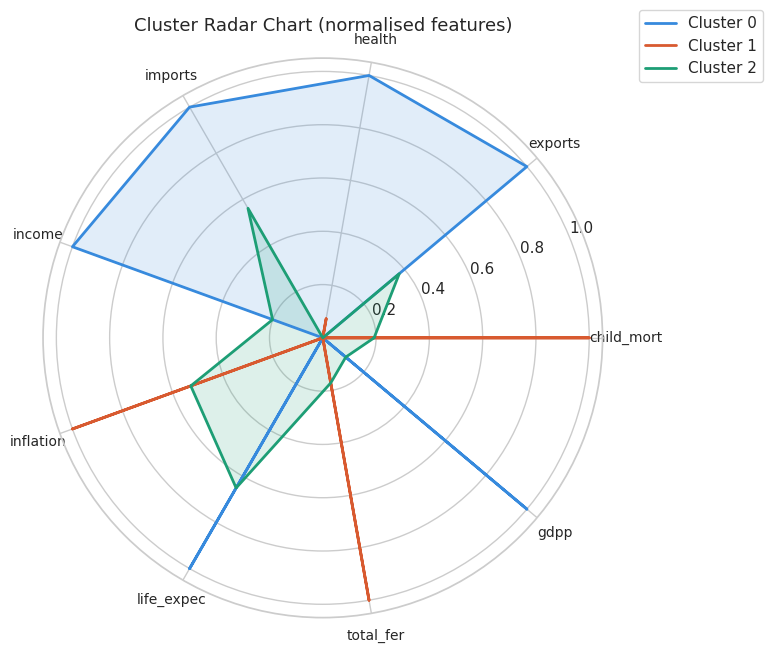

In [19]:
from matplotlib.patches import FancyArrowPatch
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

categories = list(profile_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

colors = ['#378ADD', '#D85A30', '#1D9E75']
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (idx, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2, label=f'Cluster {idx}')
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title('Cluster Radar Chart (normalised features)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [20]:
for c in sorted(df['kmeans_cluster'].unique()):
    countries = df[df['kmeans_cluster'] == c]['country'].sort_values().tolist()
    print(f'\n── Cluster {c} ({len(countries)} countries) ──')
    print(', '.join(countries))


── Cluster 0 (36 countries) ──
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

── Cluster 1 (47 countries) ──
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

── Cluster 2 (84 countries) ──
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Aze

In [21]:
X = df[numeric_cols].values
y = df['kmeans_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== Random Forest — Test Set Report ===')
print(classification_report(y_test, y_pred_rf, target_names=[f'Cluster {c}' for c in sorted(np.unique(y))]))

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== Random Forest — Test Set Report ===
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         9
   Cluster 1       0.92      0.92      0.92        12
   Cluster 2       0.95      0.95      0.95        21

    accuracy                           0.95        42
   macro avg       0.96      0.96      0.96        42
weighted avg       0.95      0.95      0.95        42

5-Fold CV Accuracy: 0.9638 ± 0.0354


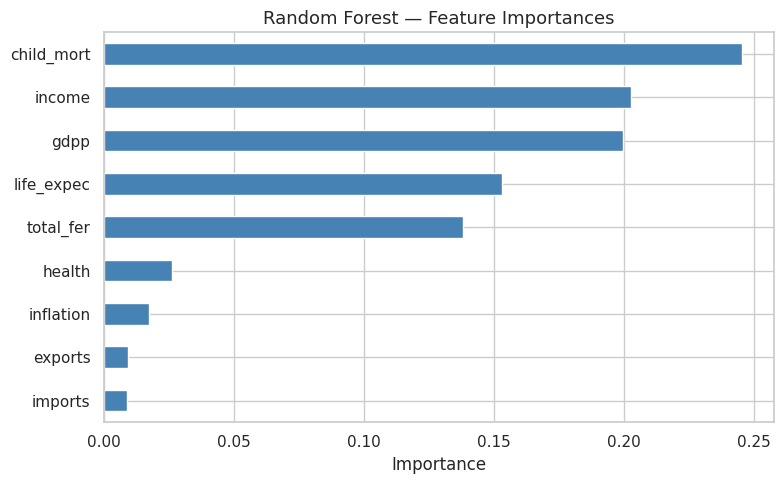

In [22]:
importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

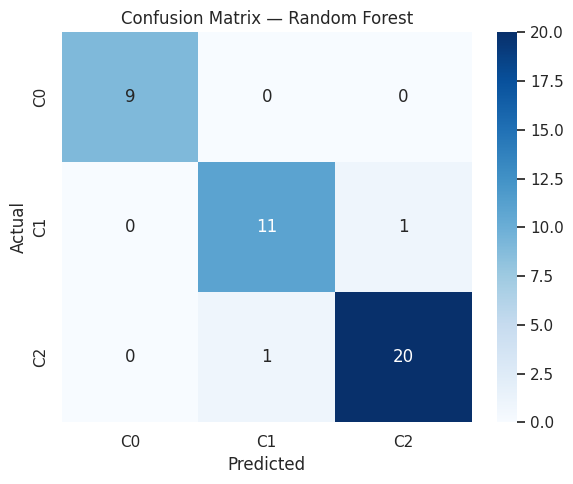

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'C{c}' for c in sorted(np.unique(y))],
            yticklabels=[f'C{c}' for c in sorted(np.unique(y))])
plt.title('Confusion Matrix — Random Forest', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [26]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print('=== XGBoost — Test Set Report ===')
print(classification_report(y_test, y_pred_xgb, target_names=[f'Cluster {c}' for c in sorted(np.unique(y))]))

cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}')

=== XGBoost — Test Set Report ===
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         9
   Cluster 1       1.00      0.92      0.96        12
   Cluster 2       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42

5-Fold CV Accuracy: 0.9701 ± 0.0186


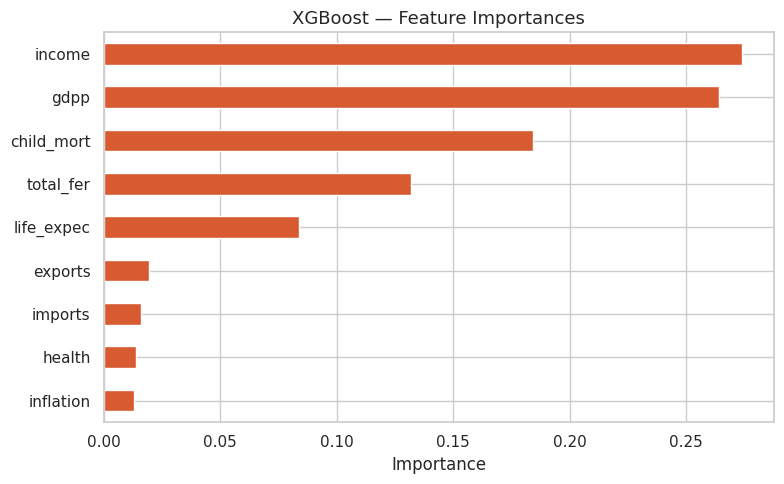

In [27]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=numeric_cols).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
xgb_imp.plot(kind='barh', color='#D85A30', edgecolor='white')
plt.title('XGBoost — Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, f1_score
comparison = pd.DataFrame({
    'Model'       : ['Random Forest', 'XGBoost'],
    'Test Acc'    : [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'F1 (macro)'  : [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro')
    ],
    'CV Acc (mean)': [cv_scores.mean(), cv_scores_xgb.mean()],
    'CV Acc (std)' : [cv_scores.std(),  cv_scores_xgb.std()]
}).round(4)
display(comparison)

,Model,Test Acc,F1 (macro),CV Acc (mean),CV Acc (std)
0,Random Forest,0.9524,0.9563,0.9638,0.0354
1,XGBoost,0.9762,0.9778,0.9701,0.0186


In [29]:
cluster_labels = {}
for c in sorted(df['kmeans_cluster'].unique()):
    sub = df[df['kmeans_cluster'] == c]
    avg_income    = sub['income'].mean()
    avg_child_mort = sub['child_mort'].mean()

    if avg_income > 20000:
        label = 'Developed / High-Income'
    elif avg_child_mort > 60:
        label = 'Underdeveloped / Aid Priority'
    else:
        label = 'Developing / Mid-Income'

    cluster_labels[c] = label
    print(f'Cluster {c}  →  {label}')
    print(f'   Avg Income    : ${avg_income:,.0f}')
    print(f'   Avg GDPP      : ${sub["gdpp"].mean():,.0f}')
    print(f'   Avg Child Mort: {avg_child_mort:.1f} per 1000')
    print(f'   Avg Life Exp  : {sub["life_expec"].mean():.1f} yrs')
    print(f'   Countries     : {len(sub)}')
    print()

Cluster 0  →  Developed / High-Income
   Avg Income    : $45,672
   Avg GDPP      : $42,494
   Avg Child Mort: 5.0 per 1000
   Avg Life Exp  : 80.1 yrs
   Countries     : 36

Cluster 1  →  Underdeveloped / Aid Priority
   Avg Income    : $3,942
   Avg GDPP      : $1,922
   Avg Child Mort: 93.0 per 1000
   Avg Life Exp  : 59.2 yrs
   Countries     : 47

Cluster 2  →  Developing / Mid-Income
   Avg Income    : $12,306
   Avg GDPP      : $6,486
   Avg Child Mort: 21.9 per 1000
   Avg Life Exp  : 72.8 yrs
   Countries     : 84



In [30]:
worst_cluster = df.groupby('kmeans_cluster')['child_mort'].mean().idxmax()
aid_countries = (
    df[df['kmeans_cluster'] == worst_cluster]
    .sort_values('child_mort', ascending=False)[['country', 'child_mort', 'gdpp', 'life_expec']]
    .head(15)
)

print(f'Top 15 Aid-Priority Countries (Cluster {worst_cluster}):')
display(aid_countries)

Top 15 Aid-Priority Countries (Cluster 1):


,country,child_mort,gdpp,life_expec
66,Haiti,208.0,662,32.1
132,Sierra Leone,160.0,399,55.0
32,Chad,150.0,897,56.5
31,Central African Republic,149.0,446,47.5
97,Mali,137.0,708,59.5
113,Nigeria,130.0,2330,60.5
112,Niger,123.0,348,58.8
3,Angola,119.0,3530,60.1
25,Burkina Faso,116.0,575,57.9
37,"Congo, Dem. Rep.",116.0,334,57.5


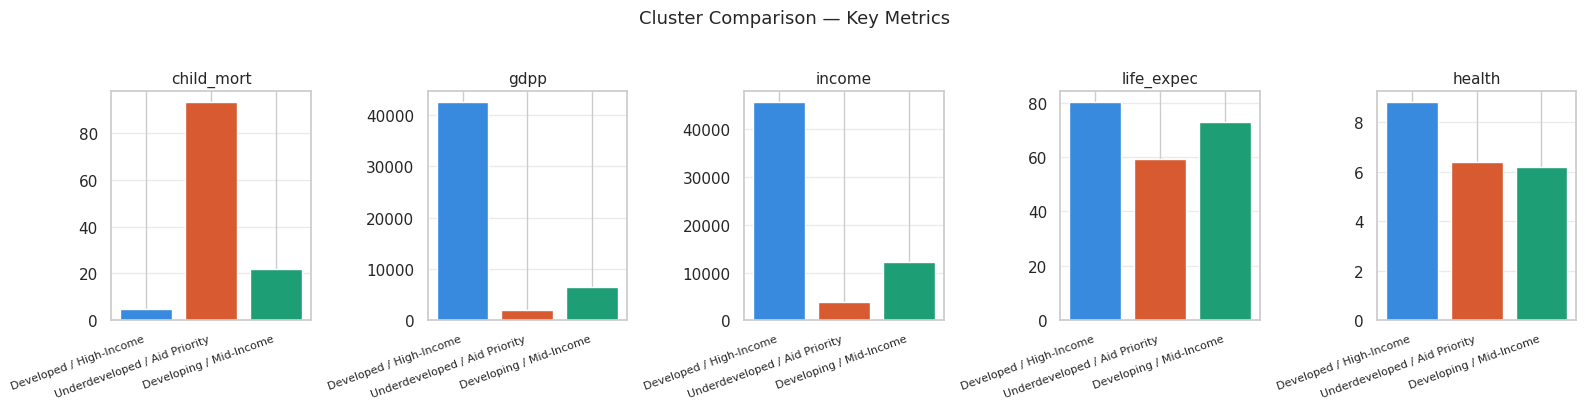

In [31]:
metrics = ['child_mort', 'gdpp', 'income', 'life_expec', 'health']
labels  = [cluster_labels[c] for c in sorted(df['kmeans_cluster'].unique())]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))
colors = ['#378ADD', '#D85A30', '#1D9E75']
for i, metric in enumerate(metrics):
    vals = [profile.loc[c, metric] for c in sorted(df['kmeans_cluster'].unique())]
    axes[i].bar(labels, vals, color=colors[:len(labels)], edgecolor='white')
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
    axes[i].grid(axis='y', alpha=0.4)
plt.suptitle('Cluster Comparison — Key Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [32]:
output_path = "/kaggle/working/country_segmentation_results.csv"

df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /kaggle/working/country_segmentation_results.csv
